In [ ]:
import pandas as pd
import numpy as np

# 1. 讀取與日期轉換
df = pd.read_csv('merged_call_sales_data.csv')
df['call_date'] = pd.to_datetime(df['call_date'])
df['order_date'] = pd.to_datetime(df['order_date'])
df['total_price'] = df['total_price'].fillna(0)

# 2. 定義基礎行為指標
df['is_pickup'] = (df['call_time_sec'] > 0).astype(int)
df['has_order'] = df['sales_order_number'].notnull().astype(int)
df['is_unreachable'] = (df['call_status_2'] == '沒聯絡上本人').astype(int)

# 3. 特徵聚合 (只保留與模型相關的數據)
model_data = df.groupby('member_id').agg(
    recency_purchase_date=('order_date', 'max'),  # 用於算購買天數
    total_spend=('total_price', 'sum'),           
    purchase_count=('has_order', 'sum'),          
    call_count=('call_id', 'count'),              # 通話頻率
    avg_call_time=('call_time_sec', 'mean'),      # 溝通深度
    pickup_rate=('is_pickup', 'mean'),            # 接聽率
    unreachable_rate=('is_unreachable', 'mean'),  # 聯絡難度
    last_call_date=('call_date', 'max'),          # 用於算通話天數
    label=('label', 'first')                      # 正確答案
).reset_index()

# 4. 天數化處理 (將日期轉為純數字天數)
latest_date = df['call_date'].max()
model_data['recency_call_days'] = (latest_date - model_data['last_call_date']).dt.days
model_data['recency_purchase_days'] = (latest_date - model_data['recency_purchase_date']).dt.days

# 處理沒買過東西的人，填入 999 代表極久沒購買
model_data['recency_purchase_days'] = model_data['recency_purchase_days'].fillna(999)

# 5. 只挑選有標籤的訓練集並編碼
final_train_set = model_data[model_data['label'].notnull()].copy()
label_map = {'churn': 0, 'partial churn': 1, 'loyal': 2}
final_train_set['target'] = final_train_set['label'].map(label_map)

# 6. 【關鍵：只保留模型需要的特徵】
# 這裡我們把日期欄位 (last_date) 和文字標籤 (label) 都剔除
keep_features = [
    'member_id', 'recency_purchase_days', 'purchase_count', 'total_spend',
    'recency_call_days', 'call_count', 'avg_call_time', 'pickup_rate', 
    'unreachable_rate', 'target'
]

# 儲存最終乾淨的資料集
final_train_set[keep_features].to_csv('model_data.csv', index=False)

print("--- 資料集精煉完成 ---")
print(f"生成的欄位共有: {len(keep_features)} 個")
print(final_train_set[keep_features].head())

--- 資料集精煉完成 ---
生成的欄位共有: 10 個
         member_id  recency_purchase_days  purchase_count  total_spend  \
4   C0980100000509                  999.0               0          0.0   
11  C0980100000967                  999.0               0          0.0   
19  C0980100002763                  999.0               0          0.0   
48  C0980100011840                  999.0               0          0.0   
55  C0980100013721                  999.0               0          0.0   

    recency_call_days  call_count  avg_call_time  pickup_rate  \
4                 219           6      80.000000     0.500000   
11                 65          18      30.888889     0.277778   
19                184           5     107.000000     0.400000   
48                  9          11      53.363636     0.727273   
55                 75           9     172.888889     0.888889   

    unreachable_rate  target  
4           0.333333       0  
11          0.444444       1  
19          0.600000       1  
48        

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# 1. 讀取資料集
data = pd.read_csv('model_data.csv')

# 2. 定義特徵 (確保與你的 model_data.csv 欄位完全一致)
features = [
    'recency_purchase_days', # 購買近期性 (R)
    'purchase_count',        # 購買頻率 (F)
    'total_spend',           # 消費金額 (M)
    'recency_call_days',     # 通話近期性
    'call_count',            # 通話頻率
    'avg_call_time',         # 平均通話長度
    'pickup_rate',           # 接聽率
    'unreachable_rate'       # 沒聯絡上比例
]

X = data[features]
y = data['target']

# 3. 切分訓練集與測試集 (80/20, 並使用 stratify 保持類別比例)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. 模型訓練 (建議加入 class_weight='balanced' 處理資料不平衡)
model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# 5. 評估模型
y_pred = model.predict(X_test)
target_names = ['churn', 'partial churn', 'loyal'] 

print(f"模型準確度: {accuracy_score(y_test, y_pred):.4f}")
print("\n分類報告:\n", classification_report(y_test, y_pred, target_names=target_names))

# 6. 特徵重要性分析
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n影響忠誠度的關鍵因素：")
print(importances)

模型準確度: 0.6680

分類報告:
                precision    recall  f1-score   support

        churn       0.75      0.85      0.80       283
partial churn       0.47      0.35      0.40       133
        loyal       0.56      0.53      0.54        66

     accuracy                           0.67       482
    macro avg       0.59      0.58      0.58       482
 weighted avg       0.65      0.67      0.65       482


影響忠誠度的關鍵因素：
                 Feature  Importance
4             call_count    0.230938
3      recency_call_days    0.165565
7       unreachable_rate    0.165563
6            pickup_rate    0.098625
2            total_spend    0.093195
5          avg_call_time    0.089716
0  recency_purchase_days    0.086182
1         purchase_count    0.070215


In [21]:
print(data['target'].value_counts(normalize=True))

target
0    0.586622
1    0.275862
2    0.137516
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. 讀取你整理好的特徵資料集
data = pd.read_csv('model_data.csv')

# 2. 定義特徵與目標
features = [
    'recency_purchase_days', # 購買近期性 (R)
    'purchase_count',        # 購買頻率 (F)
    'total_spend',           # 消費金額 (M)
    'recency_call_days',     # 通話近期性
    'call_count',            # 通話頻率
    'avg_call_time',         # 平均通話長度
    'pickup_rate',           # 接聽率
    'unreachable_rate'       # 沒聯絡上比例
]
X = data[features]
y = data['target']

# 3. 固定比例切分 (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. 定義多個模型進行測試
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# 5. 循環訓練並比較結果
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score (Weighted)": f1_score(y_test, y_pred, average='weighted'),
        "Macro F1 ": f1_score(y_test, y_pred, average='macro')
    })

# 6. 輸出精簡的對比表格
print(pd.DataFrame(results).sort_values(by="Accuracy", ascending=False))

/opt/anaconda3/envs/peter/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/peter/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/peter/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/peter/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:339: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/envs/peter/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:339: Runti

                 Model  Accuracy  F1-Score (Weighted)  Macro F1 
2              XGBoost  0.668050             0.653773   0.581137
1        Random Forest  0.641079             0.619985   0.536815
0  Logistic Regression  0.537344             0.551073   0.486851


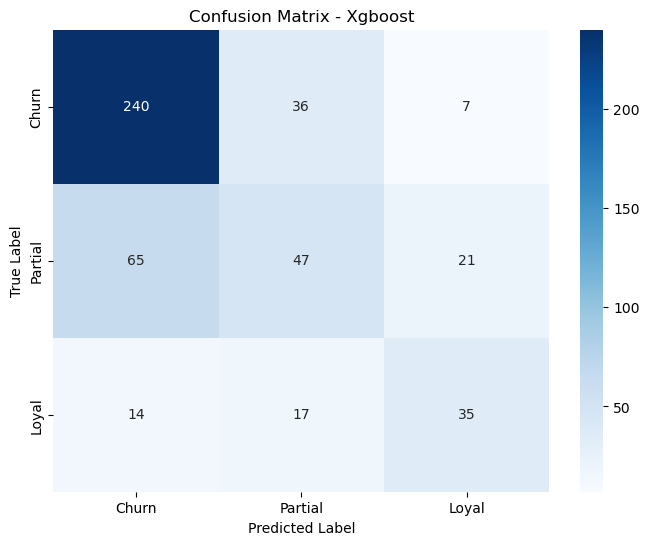

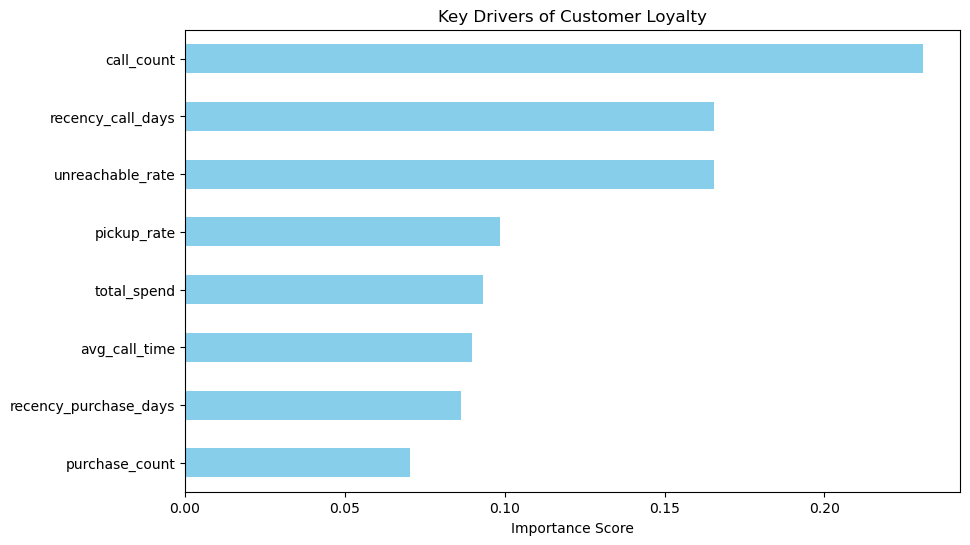

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. 使用最佳模型與平衡權重
# class_weight='balanced' 可以幫助解決 loyal 樣本太少的問題
best_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
best_model.fit(X_train, y_train)

# 2. 繪製混淆矩陣 (Confusion Matrix)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Churn', 'Partial', 'Loyal'], 
            yticklabels=['Churn', 'Partial', 'Loyal'])
plt.title('Confusion Matrix - Xgboost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. 繪製特徵重要性 (Feature Importance)
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Key Drivers of Customer Loyalty')
plt.xlabel('Importance Score')
plt.show()

In [11]:
from xgboost import XGBClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

model_data = pd.read_csv('model_data.csv')

# 重新定義 X, y (使用你提供的 model_data.csv 特徵邏輯)
features = [
    'recency_purchase_days', 'purchase_count', 'total_spend', 
    'recency_call_days', 'call_count', 'avg_call_time', 
    'pickup_rate', 'unreachable_rate'
]
X = model_data[features]
y = model_data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 調整模型參數以提高表現
model = XGBClassifier(
    n_estimators=200,      # 增加樹的數量
    learning_rate=0.05,    # 降低學習率讓模型學得更細緻
    max_depth=5,           # 限制深度防止過擬合
    subsample=0.8,         # 每次用 80% 資料隨機訓練，增加泛化能力
    colsample_bytree=0.8, 
    scale_pos_weight=(len(y)-y.sum())/y.sum(),
    eval_metric='auc'      # 以 AUC 作為優化指標
)

model.fit(X_train, y_train)

/opt/anaconda3/envs/peter/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:18:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [20]:
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. 取得機率並確保是一維 (這是你已經加好的)
y_prob = model.predict_proba(X_test)[:, 1]

# 2. 徹底清洗 y_test
# 如果 label 是 2022_label.csv 來的，可能有 1.0, 0.0 或 NaN
# 我們強制：只要不是 1，通通變成 0
y_test_binary = np.where(y_test.values == 1, 1, 0)

# 3. 診斷輸出
print(f"y_test 獨特值: {np.unique(y_test_binary)}") # 這裡應該只能出現 [0 1]
print(f"y_prob 的前 5 個數值: {y_prob[:5]}")        # 這裡應該是 0~1 之間的浮點數

# 4. 再次嘗試
try:
    auc_val = roc_auc_score(y_test_binary, y_prob)
    print(f"✅ 終於成功了！AUC 分數: {auc_val:.4f}")
except Exception as e:
    print(f"🔥 報錯原因：{e}")
    print(f"y_test 的類型: {type(y_test_binary)}")
    print(f"y_prob 的維度: {y_prob.shape}")

y_test 獨特值: [0 1]
y_prob 的前 5 個數值: [0.53555304 0.26583293 0.6617657  0.0054222  0.28784493]
✅ 終於成功了！AUC 分數: 0.7306


In [21]:
# 取得教師模型（XGBoost）對訓練集的預測機率
teacher_train_probs = model.predict_proba(X_train)[:, 1]

In [22]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

# --- 實驗 A：一般學生 (直接學習原始標籤 0/1) ---
# 使用 Classifier，因為目標是類別
student_simple = DecisionTreeClassifier(max_depth=5, random_state=42)
student_simple.fit(X_train, y_train)

# --- 實驗 B：蒸餾學生 (學習教師的預測機率) ---
# 使用 Regressor，因為教師給的機率是連續數值 (0.0 ~ 1.0)
student_distilled = DecisionTreeRegressor(max_depth=5, random_state=42)
student_distilled.fit(X_train, teacher_train_probs)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [24]:
import numpy as np
from sklearn.metrics import roc_auc_score

# --- 1. 取得預測機率 ---
# 確保教師與一般學生都只取第二欄 [:, 1]
prob_teacher = model.predict_proba(X_test)[:, 1]
prob_student_simple = student_simple.predict_proba(X_test)[:, 1]
prob_student_distilled = student_distilled.predict(X_test) # Regressor 直接輸出

# --- 2. 資料強制清洗 (解決 ValueError 的核心) ---
# 強制 y_test 轉為 numpy array 並過濾掉任何非 0/1 的值
# 假設成交是 1，其餘皆為 0
y_test_clean = np.where(y_test.values == 1, 1, 0)

# --- 3. 計算 AUC 分數 ---
try:
    auc_teacher = roc_auc_score(y_test_clean, prob_teacher)
    auc_student_simple = roc_auc_score(y_test_clean, prob_student_simple)
    auc_student_distilled = roc_auc_score(y_test_clean, prob_student_distilled)

    print(f"【教師模型 XGBoost】     AUC: {auc_teacher:.4f}")
    print(f"【一般學生 DecisionTree】 AUC: {auc_student_simple:.4f}")
    print(f"【蒸餾學生 DecisionTree】 AUC: {auc_student_distilled:.4f}")

except Exception as e:
    print(f"❌ 錯誤訊息: {e}")
    # 如果還是錯，印出數據狀態診斷
    print(f"y_test 獨特值: {np.unique(y_test_clean)}")
    print(f"教師預測維度: {prob_teacher.shape}")

【教師模型 XGBoost】     AUC: 0.7306
【一般學生 DecisionTree】 AUC: 0.6785
【蒸餾學生 DecisionTree】 AUC: 0.6552


/var/folders/bc/3gcv0zzj4fgcc8gzvkdcr1940000gn/T/ipykernel_59496/856533053.py:14: UserWarning: Glyph 33976 (\N{CJK UNIFIED IDEOGRAPH-84B8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bc/3gcv0zzj4fgcc8gzvkdcr1940000gn/T/ipykernel_59496/856533053.py:14: UserWarning: Glyph 39230 (\N{CJK UNIFIED IDEOGRAPH-993E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bc/3gcv0zzj4fgcc8gzvkdcr1940000gn/T/ipykernel_59496/856533053.py:14: UserWarning: Glyph 23416 (\N{CJK UNIFIED IDEOGRAPH-5B78}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bc/3gcv0zzj4fgcc8gzvkdcr1940000gn/T/ipykernel_59496/856533053.py:14: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bc/3gcv0zzj4fgcc8gzvkdcr1940000gn/T/ipykernel_59496/856533053.py:14: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bc/3gcv0zzj4

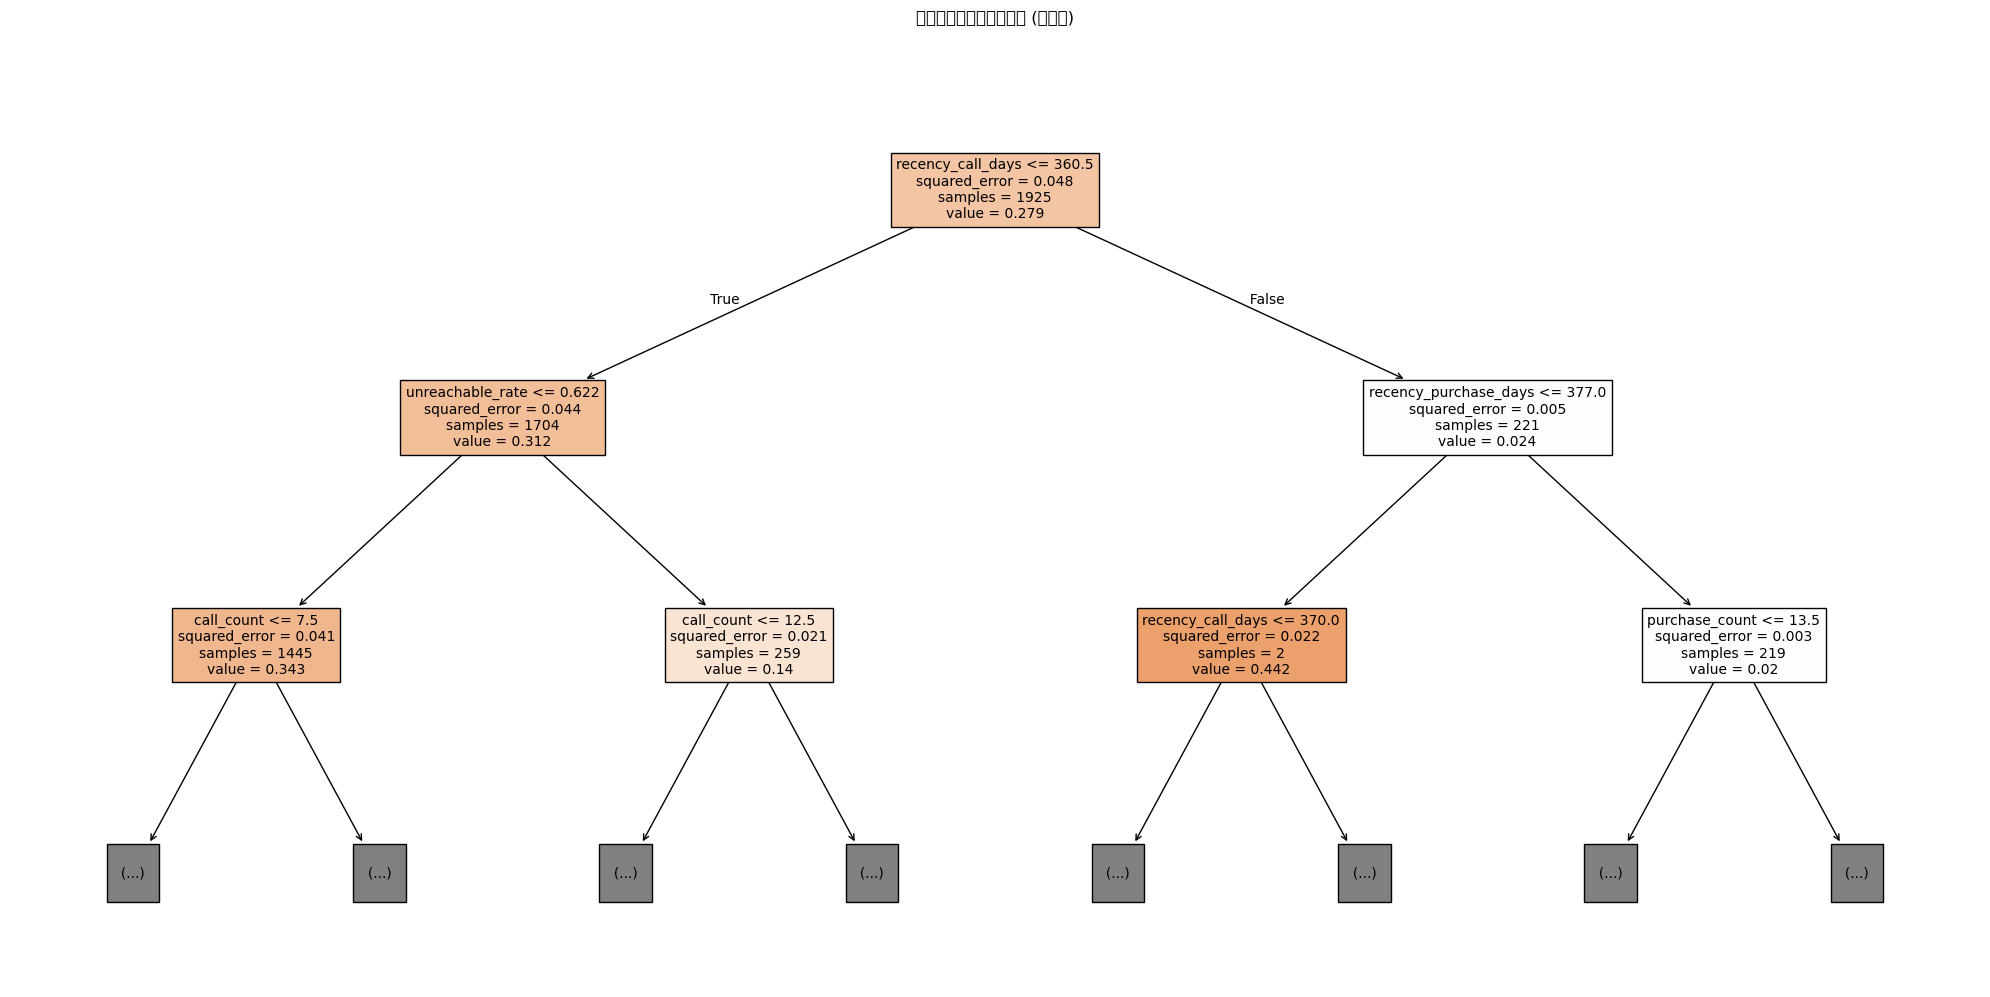

In [27]:
from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    student_distilled,
    feature_names=X.columns,
    filled=True,
    max_depth=2,
    fontsize=10,
    ax=ax
)

ax.set_title("蒸餾學生模型的決策邏輯 (前兩層)", y=1.05)
plt.tight_layout()
plt.show()
